In [15]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp
import deepssfp.analysis

In [16]:
modes=['BandRemoval:4', 'BandRemoval:2', 'SuperFOV', 'SuperFOVi', 'SyntheticBanding']
model_dir = "D:/DeepSSFP/"
model_name="brain_phantom_dropout0_1"

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def plot_dataset(data, slice=None, cmap='gray', figsize=(5, 5)):
    ''' Plots a slice of dataset of form: [Slice, Height, Width, Channel] '''

    slice = 0 if slice is None else slice
    npcs = data.shape[3]
    nx, ny = 2, int(npcs / 2)
    
    # Create figure with adjusted layout
    fig, axs = plt.subplots(nx, ny, figsize=figsize, constrained_layout=True)
    
    if cmap:
        plt.set_cmap(cmap)
    
    # Flatten axs array for easier iteration
    axs = axs.flatten() if nx*ny > 1 else [axs]
    
    for ii in range(nx*ny):
        _data = np.abs(data[slice, :, :, ii])
        axs[ii].imshow(_data)
        axs[ii].set_title(f'{int(ii*(360/npcs))}°')  # Using the degree symbol
        axs[ii].set_xticks([])
        axs[ii].set_yticks([])
    
    # Adjust layout to reduce space between subplots
    plt.tight_layout()
    plt.show()

In [18]:
dataset = mssfp.generate_ssfp_dataset(
    phantom_type='brain', 
    npcs=4, 
    f=500, 
    alpha=np.deg2rad(60), 
    sigma=0.001, 
    data_indices=[(0, 2), (120,180)], 
    rotation=90,
    useRotate=True, 
    useDeform=True
)

Generating phantom...
Generating 3D phantom: (120, 434, 362)
Generating SSFP dataset...
Dataset complete.
Dataset shape: (120, 256, 256, 4)


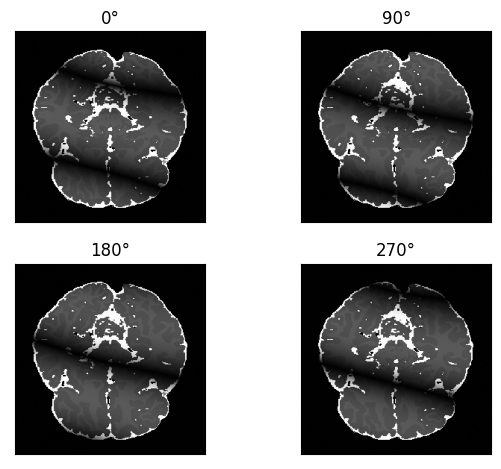

In [19]:
plot_dataset(dataset['M'], slice=1)